ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

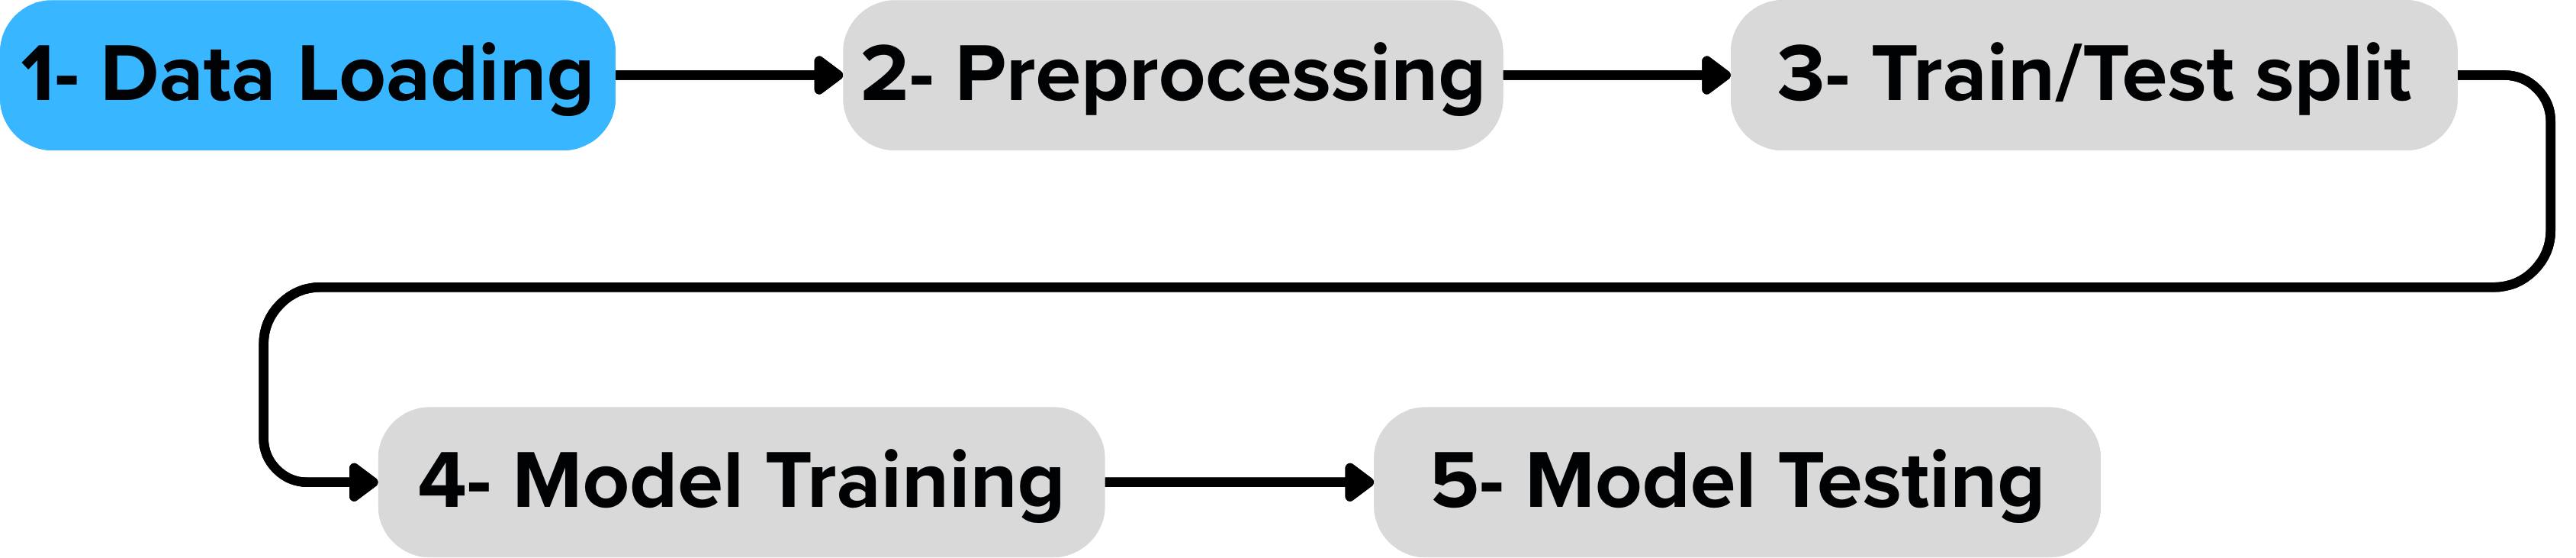

In [99]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [100]:
# Load Dataset
df = pd.read_csv("Student Mental health.csv")
# Display first 5 rows. If you want to display all rows, use df.head(-1)
df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


### Check Missing Values

In [11]:
# Check all values
print(df.isna())

     Timestamp  Choose your gender    Age  What is your course?  \
0        False               False  False                 False   
1        False               False  False                 False   
2        False               False  False                 False   
3        False               False  False                 False   
4        False               False  False                 False   
..         ...                 ...    ...                   ...   
96       False               False  False                 False   
97       False               False  False                 False   
98       False               False  False                 False   
99       False               False  False                 False   
100      False               False  False                 False   

     Your current year of Study  What is your CGPA?  Marital status  \
0                         False               False           False   
1                         False               False  

### Handling Missing Values

In [13]:
df = df.dropna()

- Missing values were removed from the dataset to ensure data completeness and improve the quality of analysis.

- Why it was needed: The dataset contained missing entries which could affect statistical calculations and visualizations.

In [14]:
print(df.isna().sum())

Timestamp                                       0
Choose your gender                              0
Age                                             0
What is your course?                            0
Your current year of Study                      0
What is your CGPA?                              0
Marital status                                  0
Do you have Depression?                         0
Do you have Anxiety?                            0
Do you have Panic attack?                       0
Did you seek any specialist for a treatment?    0
dtype: int64


### Check duplicate rows

In [90]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

### No. of rows and columns

In [105]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (101, 11) 

number of rows:  101
number of columns:  11


### Data type of columns

In [106]:
# viewing the data types of columns
df.dtypes

Timestamp                                        object
Choose your gender                               object
Age                                             float64
What is your course?                             object
Your current year of Study                       object
What is your CGPA?                               object
Marital status                                   object
Do you have Depression?                          object
Do you have Anxiety?                             object
Do you have Panic attack?                        object
Did you seek any specialist for a treatment?     object
dtype: object

### Converting Timestamp Column

In [93]:
df.loc[:, 'Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df.dtypes

Timestamp                                        object
Choose your gender                               object
Age                                             float64
What is your course?                             object
Your current year of Study                       object
What is your CGPA?                               object
Marital status                                   object
Do you have Depression?                          object
Do you have Anxiety?                             object
Do you have Panic attack?                        object
Did you seek any specialist for a treatment?     object
dtype: object

- The Timestamp column was converted from object type into datetime format.

- Why it was needed: To allow proper time-based analysis and ensure correct data type for date operations.

### Standardizing Text Values

In [94]:
df.loc[:, 'Choose your gender'] = df['Choose your gender'].astype(str).str.strip().str.lower()
df.loc[:, 'Your current year of Study'] = df['Your current year of Study'].astype(str).str.strip().str.lower()

- Text values were converted into lowercase to ensure consistency in categorical data.

- Why it was needed: To avoid duplication caused by inconsistent text formats (e.g., “Female” vs “female”).

### Converting CGPA into Numeric Format

In [95]:
df.loc[:, 'CGPA_mid'] = (
    df['What is your CGPA?']
    .str.extract(r'(\d\.\d+)')[0]
    .astype(float)
)
df['CGPA_mid'].dtype
df['CGPA_mid'].head()

0    3.0
1    3.0
2    3.0
3    3.0
4    3.0
Name: CGPA_mid, dtype: float64

- A new column (CGPA_mid) was created by extracting numeric values from the original CGPA column.

- Why it was needed: The original CGPA column was in text format (e.g., “3.00 - 3.49”), which is not suitable for numerical analysis.

## Screenshots:
### Screenshot of dataset before cleaning
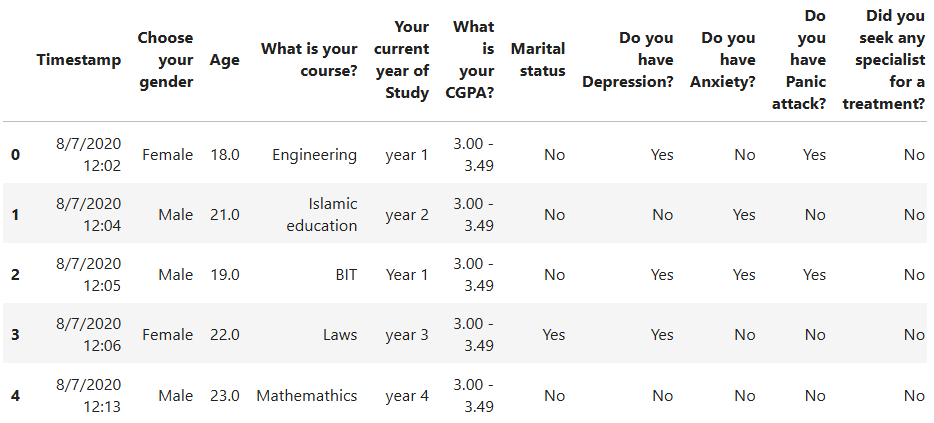

### Screenshot of dataset after cleaning
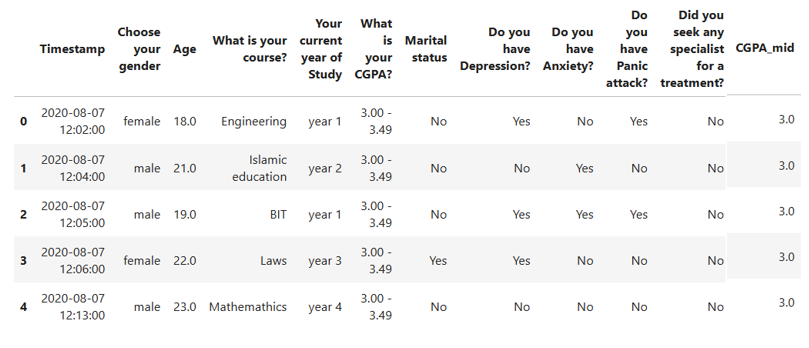

In [45]:
# Statistical summary
df.describe(include='all')

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?,CGPA_mid
count,77,100,100.00000,100,100,100,100,100,100,100,100,100.000000
unique,NaN,2,NaN,49,4,6,2,2,2,2,2,NaN
top,NaN,female,NaN,BCS,year 1,3.50 - 4.00,No,No,No,No,No,NaN
freq,NaN,75,NaN,18,42,47,84,65,66,67,94,NaN
mean,2020-08-09 15:02:36.623376640,NaN,20.53000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.169700
min,2020-08-07 12:02:00,NaN,18.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.990000
25%,2020-08-07 13:07:00,NaN,18.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000
50%,2020-08-07 14:47:00,NaN,19.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000
75%,2020-08-07 16:22:00,NaN,23.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.500000
max,2020-09-07 18:24:00,NaN,24.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.500000


### Descriptive summary Statistics

## Univariate Analysis

### Age Distribution

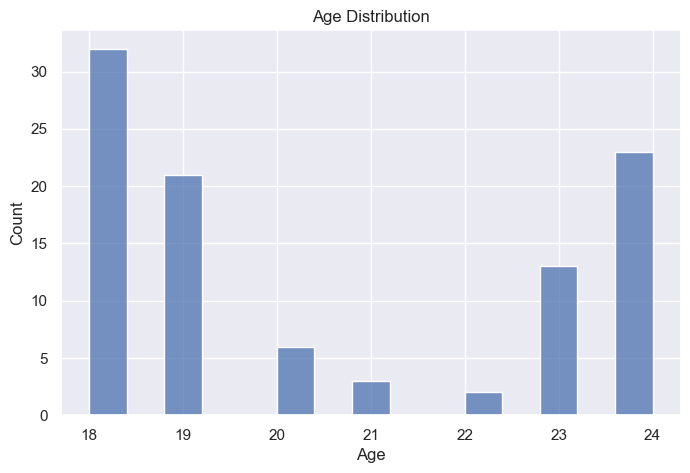

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=15)
plt.title("Age Distribution")
plt.show()

- Why this visualization? To understand the age structure of the students in the dataset.

- Insight: The dataset mainly includes students aged between 18–24, showing that the sample represents typical undergraduate students.

### CGPA Distribution

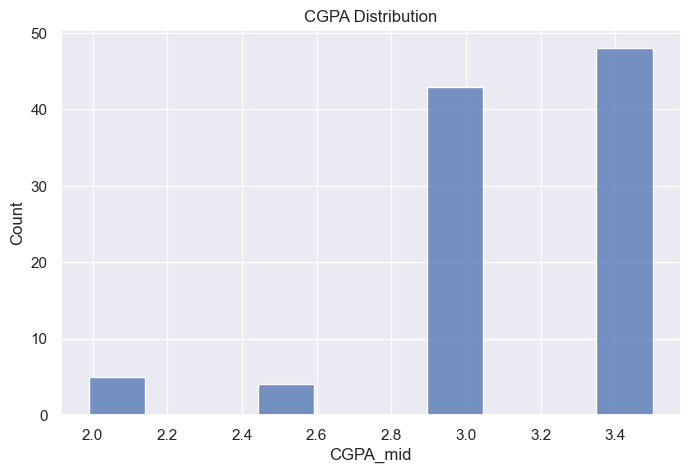

In [58]:
plt.figure(figsize=(8,5))
sns.histplot(df['CGPA_mid'], bins=10)
plt.title("CGPA Distribution")
plt.show()

- Why this visualization? To analyze academic performance levels among students.

- Insight: Most students fall within the 3.00 – 4.00 CGPA range, indicating generally good academic performance. Very few students are in low CGPA categories.

### Gender Distribution

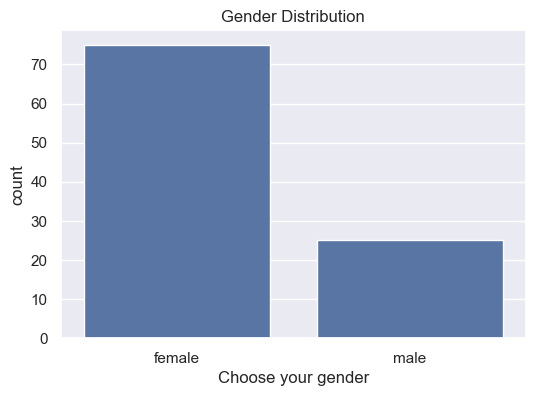

In [54]:
plt.figure(figsize=(6,4))
sns.countplot(x='Choose your gender', data=df)
plt.title("Gender Distribution")
plt.show()

- Why this visualization? To identify the gender balance in the dataset.

- Insight: The dataset is female-dominated, meaning results may slightly reflect female student experiences more than male students.

### Depression Status Among Students

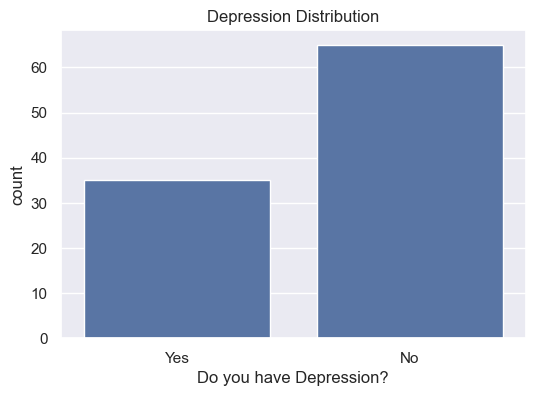

In [55]:
plt.figure(figsize=(6,4))
sns.countplot(x='Do you have Depression?', data=df)
plt.title("Depression Distribution")
plt.show()

- Why this visualization? To measure mental health conditions among students.

- Insight: A noticeable portion of students report depression, showing that mental health issues are present in the student population.

### Anxiety Status Among Students

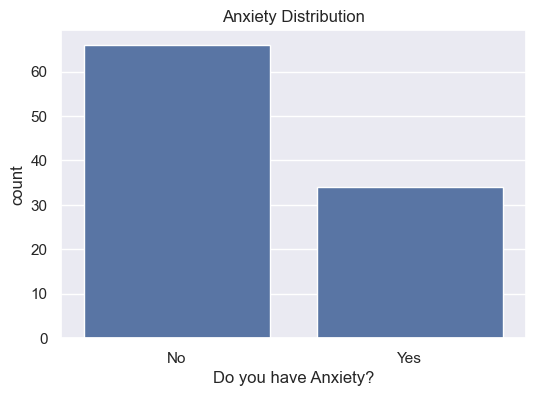

In [56]:
plt.figure(figsize=(6,4))
sns.countplot(x='Do you have Anxiety?', data=df)
plt.title("Anxiety Distribution")
plt.show()

- Why this visualization? To analyze anxiety prevalence.

- Insight: Anxiety levels are also present in a significant number of students, similar to depression patterns.


### Panic Attack Status Among Students

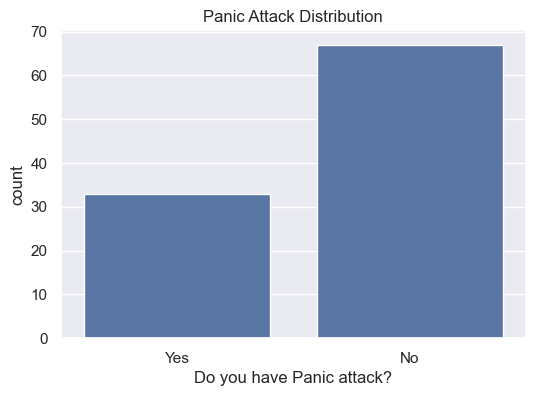

In [57]:
plt.figure(figsize=(6,4))
sns.countplot(x='Do you have Panic attack?', data=df)
plt.title("Panic Attack Distribution")
plt.show()

- Why this visualization? To examine severity of acute mental health symptoms.

- Insight: Panic attacks are less frequent compared to depression and anxiety, but still exist in a minority of students.

## Bivariate Analysis

### CGPA vs Depression

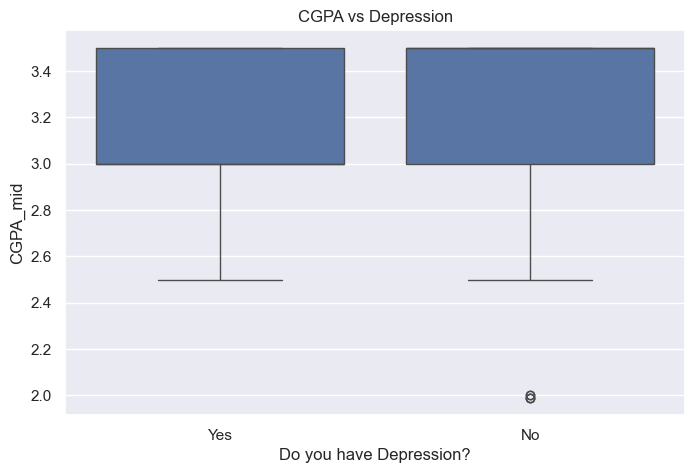

In [63]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Do you have Depression?', y='CGPA_mid', data=df)
plt.title("CGPA vs Depression")
plt.show()

- Why this visualization? To investigate whether academic performance is linked to depression.

- Insight: Students with lower CGPA ranges (0–2.99) appear more likely to report depression compared to higher-performing students.

### CGPA vs Anxiety

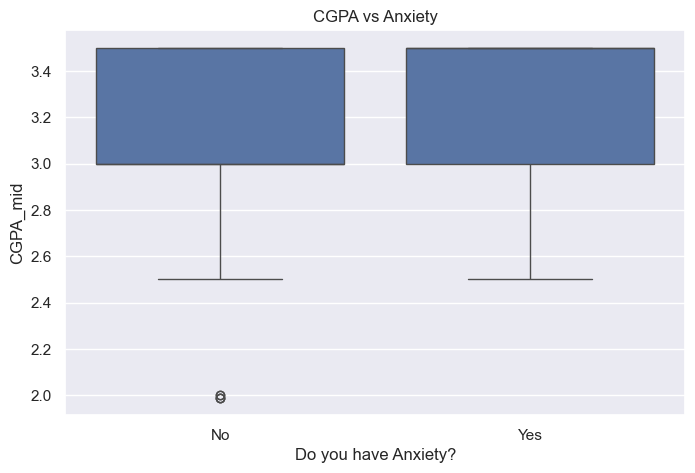

In [64]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Do you have Anxiety?', y='CGPA_mid', data=df)
plt.title("CGPA vs Anxiety")
plt.show()

- Why this visualization? To explore the relationship between academic pressure and anxiety.

- Insight: Anxiety is distributed across all CGPA levels, suggesting that academic performance is not the only factor influencing anxiety.

### Course Imapct
### Course vs Depression

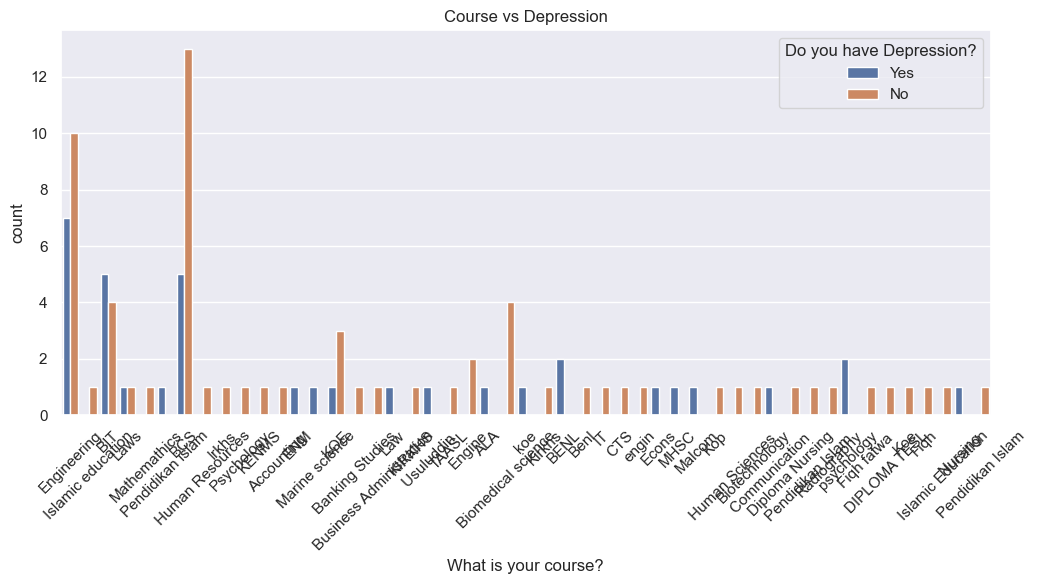

In [66]:
plt.figure(figsize=(12,5))
sns.countplot(x='What is your course?', hue='Do you have Depression?', data=df)
plt.xticks(rotation=45)
plt.title("Course vs Depression")
plt.show()

- Why this visualization? To compare mental health conditions across different academic courses.

- Insight: Courses like Engineering, BIT, and Biomedical Science show higher counts of depression cases, possibly due to higher academic pressure.

### Correlation Matrix

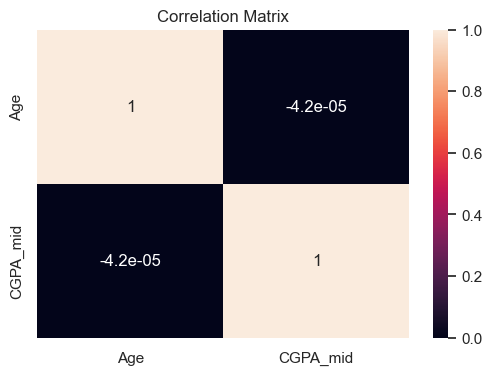

In [75]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age','CGPA_mid']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship
- Why this visualization? To check if age influences academic performance.

- Insight: There is very weak or no correlation between age and CGPA, meaning age does not significantly affect academic results in this dataset.

## Gender-Based Analysis
### Gender vs Depression

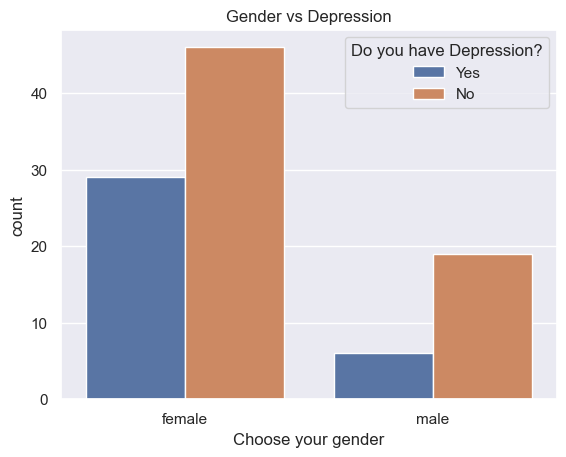

In [69]:
sns.countplot(x='Choose your gender', hue='Do you have Depression?', data=df)
plt.title("Gender vs Depression")
plt.show()

- Why this visualization? To compare depression levels between male and female students.

- Insight: Female students report slightly higher levels of depression compared to male students in this dataset.

### Gender vs Anxiety

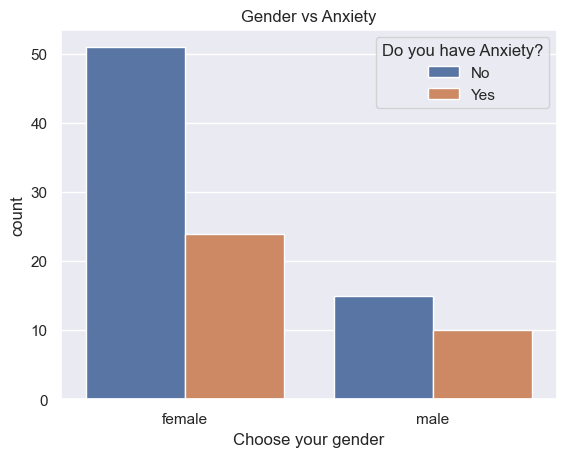

In [74]:
sns.countplot(x='Choose your gender', hue='Do you have Anxiety?', data=df)
plt.title("Gender vs Anxiety")
plt.show()

- Why this visualization? To analyze differences in anxiety between genders.

- Insight: Anxiety cases are more frequently reported among female students compared to male students.

### Gender vs Panic Attack

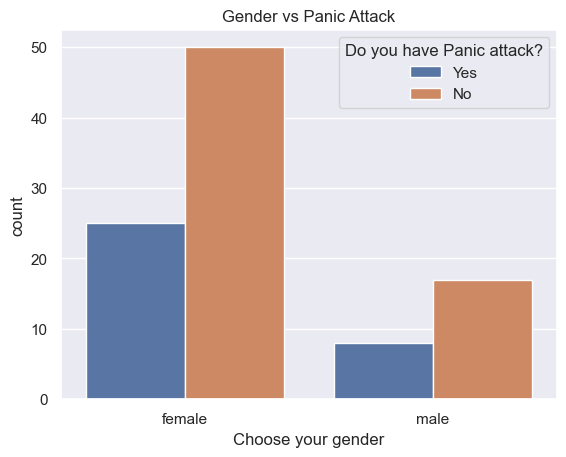

In [71]:
sns.countplot(x='Choose your gender', hue='Do you have Panic attack?', data=df)
plt.title("Gender vs Panic Attack")
plt.show()

- Why this visualization? To examine whether panic attacks differ by gender.

- Insight: Panic attacks are relatively similar across genders, with no strong difference observed.

### Gender vs CGPA

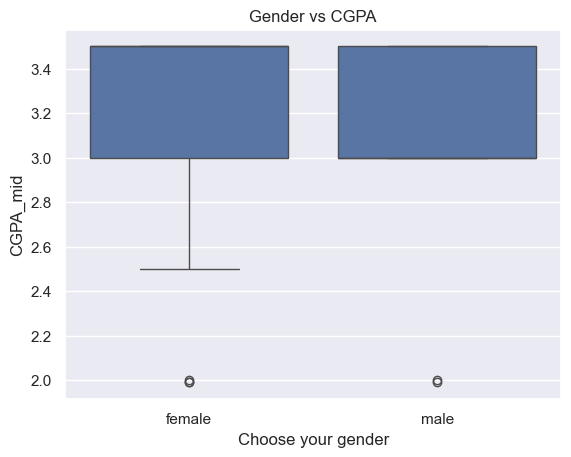

In [72]:
sns.boxplot(x='Choose your gender', y='CGPA_mid', data=df)
plt.title("Gender vs CGPA")
plt.show()

- Why this visualization? To check if academic performance varies by gender.

- Insight: There is no significant difference in CGPA between male and female students, indicating similar academic performance.

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file 
2. Dataset Description readme file
2. Jupyter Notebook
